## Working Question

Where does the risk group (`depression_label = 1`) concentrate in this dataset: around a specific platform, or around a combination of habits and psychological pressure?

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import PercentFormatter

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["savefig.dpi"] = 160
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11

DATA_PATH = Path("Teen_Mental_Health_Dataset.csv")
FIG_DIR = Path("hw_figures")
FIG_DIR.mkdir(exist_ok=True)

BASE = "#B8BEC8"
ACCENT = "#E45756"
BLUE = "#4C78A8"

ModuleNotFoundError: No module named 'numpy'

In [2]:
df = pd.read_csv(DATA_PATH)

df["depression_group"] = df["depression_label"].map({0: "No risk label", 1: "Risk label"})
df["platform_clean"] = df["platform_usage"].map({"Instagram": "Instagram", "TikTok": "TikTok", "Both": "Both platforms"})
df["gender_clean"] = df["gender"].map({"male": "Male", "female": "Female"})
df["social_interaction_clean"] = df["social_interaction_level"].map({"low": "Low", "medium": "Medium", "high": "High"})

summary = pd.DataFrame({
    "Metric": ["Rows", "Columns", "Missing values", "Share with depression_label=1"],
    "Value": [len(df), df.shape[1] - 4, int(df.isna().sum().sum()), f"{df['depression_label'].mean():.1%}"],
})
summary

,Metric,Value
0,Rows,1200
1,Columns,13
2,Missing values,0
3,Share with depression_label=1,2.6%


## Chart 1. First check: is this mainly about the platform?

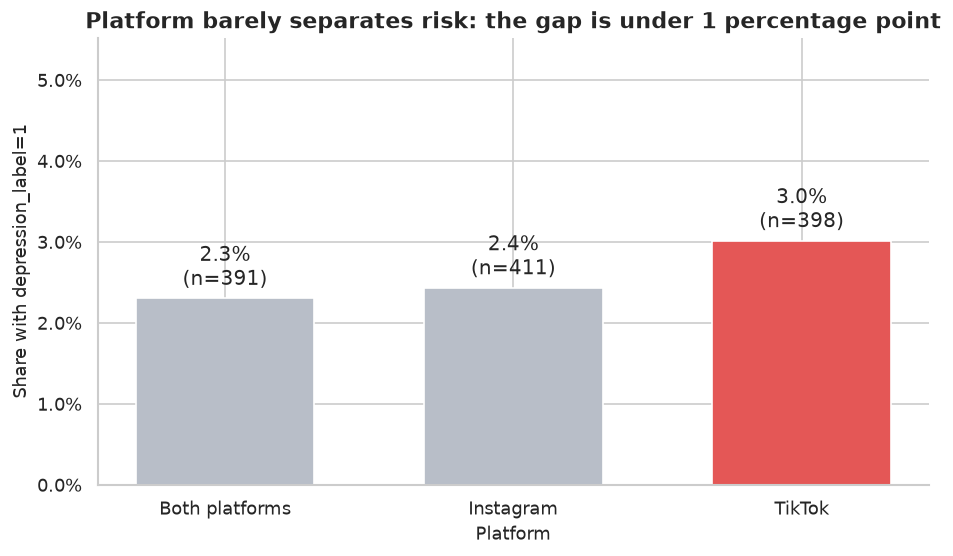

In [3]:
platform_rate = (
    df.groupby("platform_clean", observed=True)
      .agg(teenagers=("depression_label", "size"), risk_rate=("depression_label", "mean"))
      .reset_index()
      .sort_values("risk_rate")
)
platform_rate["risk_pct"] = platform_rate["risk_rate"] * 100

fig, ax = plt.subplots(figsize=(8, 4.8))
colors = [BASE if v < platform_rate["risk_pct"].max() else ACCENT for v in platform_rate["risk_pct"]]
bars = ax.bar(platform_rate["platform_clean"], platform_rate["risk_pct"], color=colors, width=0.62)

ax.bar_label(bars, labels=[f"{v:.1f}%\n(n={n})" for v, n in zip(platform_rate["risk_pct"], platform_rate["teenagers"])], padding=4)
ax.set_title("Platform barely separates risk: the gap is under 1 percentage point")
ax.set_xlabel("Platform")
ax.set_ylabel("Share with depression_label=1")
ax.yaxis.set_major_formatter(PercentFormatter(xmax=100))
ax.set_ylim(0, max(platform_rate["risk_pct"]) + 2.5)
sns.despine(ax=ax)
plt.tight_layout()
plt.savefig(FIG_DIR / "01_platform_risk.png", bbox_inches="tight")
plt.show()

## Chart 2. Check social media intensity

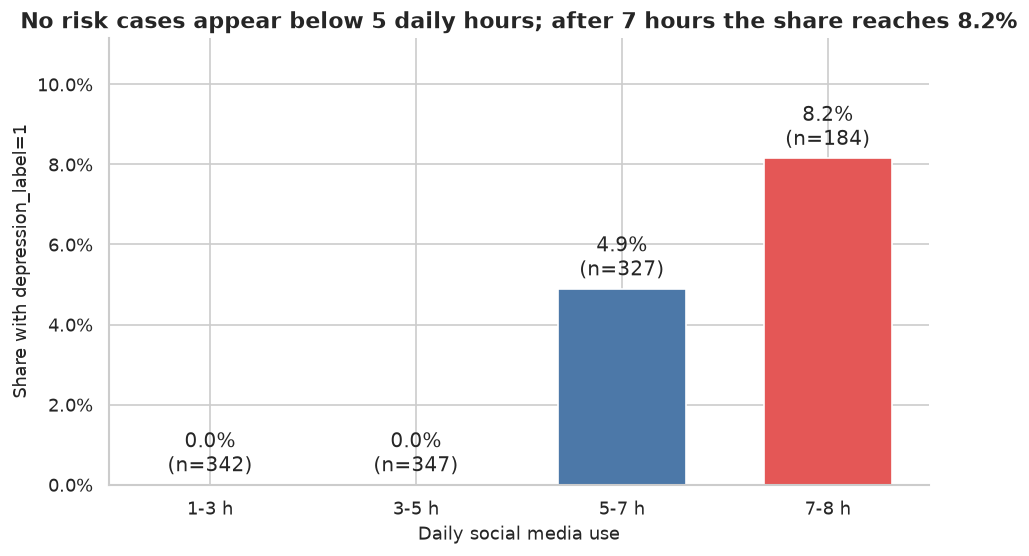

In [4]:
df["social_media_bin"] = pd.cut(
    df["daily_social_media_hours"],
    bins=[0, 3, 5, 7, 8.1],
    labels=["1-3 h", "3-5 h", "5-7 h", "7-8 h"],
    include_lowest=True,
)

social_media_rate = (
    df.groupby("social_media_bin", observed=True)
      .agg(teenagers=("depression_label", "size"), risk_rate=("depression_label", "mean"))
      .reset_index()
)
social_media_rate["risk_pct"] = social_media_rate["risk_rate"] * 100

fig, ax = plt.subplots(figsize=(8, 4.8))
colors = [BASE, BASE, BLUE, ACCENT]
bars = ax.bar(social_media_rate["social_media_bin"].astype(str), social_media_rate["risk_pct"], color=colors, width=0.62)

ax.bar_label(bars, labels=[f"{v:.1f}%\n(n={n})" for v, n in zip(social_media_rate["risk_pct"], social_media_rate["teenagers"])], padding=4)
ax.set_title("No risk cases appear below 5 daily hours; after 7 hours the share reaches 8.2%")
ax.set_xlabel("Daily social media use")
ax.set_ylabel("Share with depression_label=1")
ax.yaxis.set_major_formatter(PercentFormatter(xmax=100))
ax.set_ylim(0, max(social_media_rate["risk_pct"]) + 3)
sns.despine(ax=ax)
plt.tight_layout()
plt.savefig(FIG_DIR / "02_social_media_hours_risk.png", bbox_inches="tight")
plt.show()

## Chart 3. Check sleep as a possible protective boundary

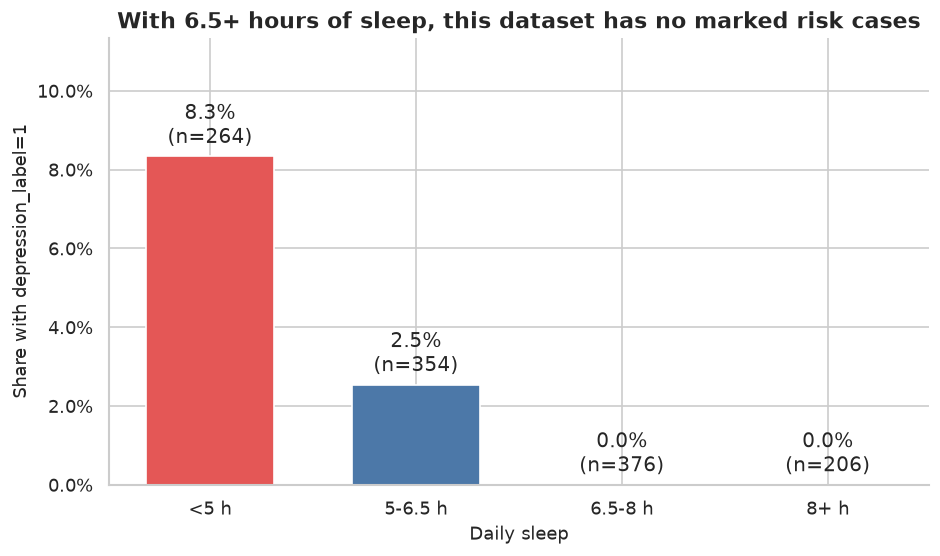

In [5]:
df["sleep_bin"] = pd.cut(
    df["sleep_hours"],
    bins=[3.9, 5, 6.5, 8, 9.1],
    labels=["<5 h", "5-6.5 h", "6.5-8 h", "8+ h"],
)

sleep_rate = (
    df.groupby("sleep_bin", observed=True)
      .agg(teenagers=("depression_label", "size"), risk_rate=("depression_label", "mean"))
      .reset_index()
)
sleep_rate["risk_pct"] = sleep_rate["risk_rate"] * 100

fig, ax = plt.subplots(figsize=(8, 4.8))
colors = [ACCENT, BLUE, BASE, BASE]
bars = ax.bar(sleep_rate["sleep_bin"].astype(str), sleep_rate["risk_pct"], color=colors, width=0.62)

ax.bar_label(bars, labels=[f"{v:.1f}%\n(n={n})" for v, n in zip(sleep_rate["risk_pct"], sleep_rate["teenagers"])], padding=4)
ax.set_title("With 6.5+ hours of sleep, this dataset has no marked risk cases")
ax.set_xlabel("Daily sleep")
ax.set_ylabel("Share with depression_label=1")
ax.yaxis.set_major_formatter(PercentFormatter(xmax=100))
ax.set_ylim(0, max(sleep_rate["risk_pct"]) + 3)
sns.despine(ax=ax)
plt.tight_layout()
plt.savefig(FIG_DIR / "03_sleep_hours_risk.png", bbox_inches="tight")
plt.show()

## Chart 4. Combine the two habits: high social media use and low sleep

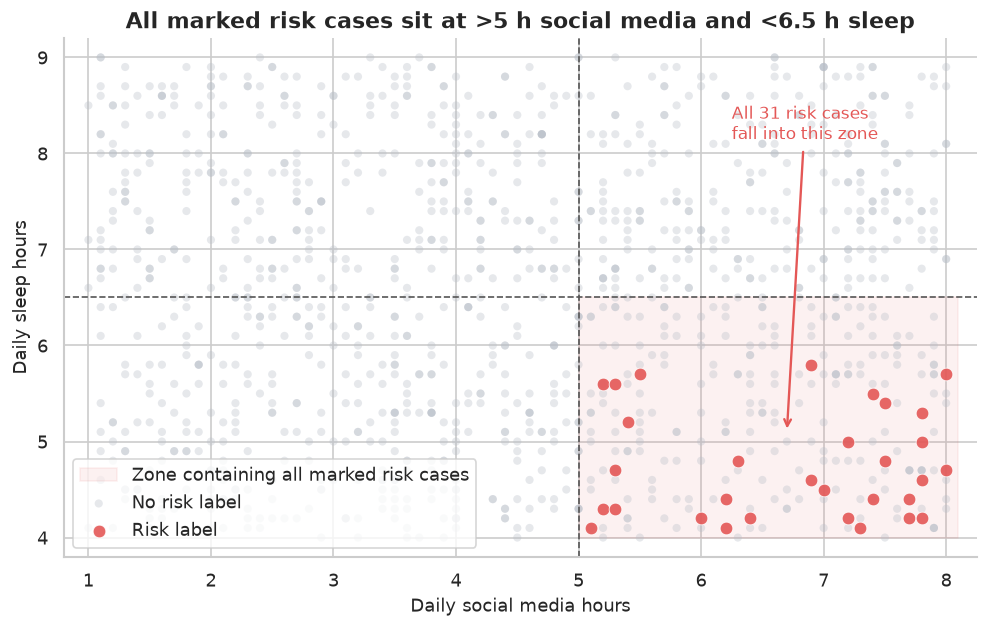

In [6]:
no_risk = df[df["depression_label"] == 0]
risk = df[df["depression_label"] == 1]

fig, ax = plt.subplots(figsize=(8.4, 5.4))
ax.fill_between([5, 8.1], 4, 6.5, color=ACCENT, alpha=0.08, label="Zone containing all marked risk cases")
ax.scatter(no_risk["daily_social_media_hours"], no_risk["sleep_hours"], s=24, color=BASE, alpha=0.35, edgecolor="none", label="No risk label")
ax.scatter(risk["daily_social_media_hours"], risk["sleep_hours"], s=58, color=ACCENT, alpha=0.9, edgecolor="white", linewidth=0.5, label="Risk label")

ax.axvline(5, color="#555555", linestyle="--", linewidth=1)
ax.axhline(6.5, color="#555555", linestyle="--", linewidth=1)
ax.annotate(
    "All 31 risk cases\nfall into this zone",
    xy=(6.7, 5.1),
    xytext=(6.25, 8.15),
    arrowprops=dict(arrowstyle="->", color=ACCENT, lw=1.4),
    color=ACCENT,
    fontsize=10,
    ha="left",
)

ax.set_title("All marked risk cases sit at >5 h social media and <6.5 h sleep")
ax.set_xlabel("Daily social media hours")
ax.set_ylabel("Daily sleep hours")
ax.set_xlim(0.8, 8.25)
ax.set_ylim(3.8, 9.2)
ax.legend(frameon=True, loc="lower left")
sns.despine(ax=ax)
plt.tight_layout()
plt.savefig(FIG_DIR / "04_social_media_sleep_zone.png", bbox_inches="tight")
plt.show()

## Chart 5. Check the joint effect of stress and anxiety

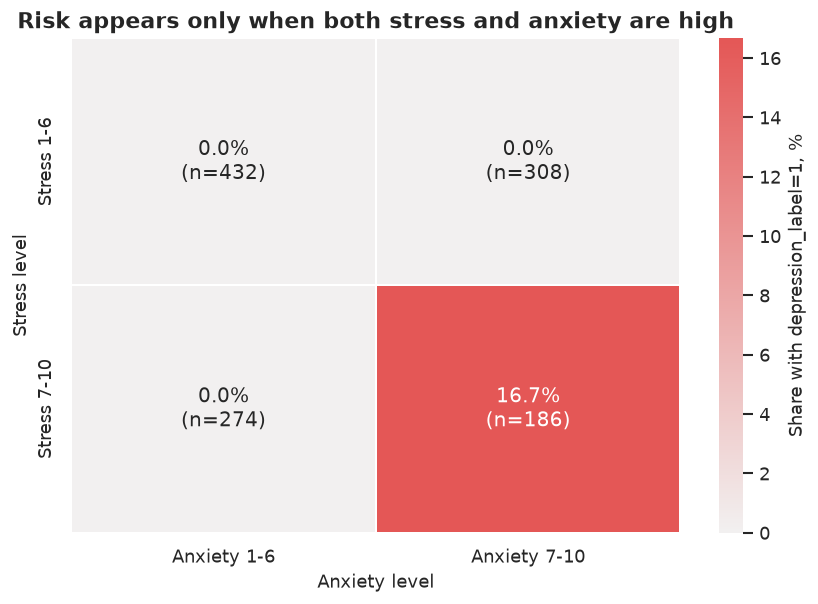

In [7]:
df["stress_group"] = pd.cut(df["stress_level"], bins=[0, 6, 10], labels=["Stress 1-6", "Stress 7-10"])
df["anxiety_group"] = pd.cut(df["anxiety_level"], bins=[0, 6, 10], labels=["Anxiety 1-6", "Anxiety 7-10"])

risk_matrix = pd.crosstab(
    df["stress_group"],
    df["anxiety_group"],
    values=df["depression_label"],
    aggfunc="mean",
).fillna(0) * 100
count_matrix = pd.crosstab(df["stress_group"], df["anxiety_group"])
annot = risk_matrix.copy().astype(str)
for row in risk_matrix.index:
    for col in risk_matrix.columns:
        annot.loc[row, col] = f"{risk_matrix.loc[row, col]:.1f}%\n(n={count_matrix.loc[row, col]})"

fig, ax = plt.subplots(figsize=(7.2, 5.2))
sns.heatmap(
    risk_matrix,
    annot=annot,
    fmt="",
    cmap=sns.light_palette(ACCENT, as_cmap=True),
    linewidths=1,
    linecolor="white",
    cbar_kws={"label": "Share with depression_label=1, %"},
    ax=ax,
)
ax.set_title("Risk appears only when both stress and anxiety are high")
ax.set_xlabel("Anxiety level")
ax.set_ylabel("Stress level")
plt.tight_layout()
plt.savefig(FIG_DIR / "05_stress_anxiety_heatmap.png", bbox_inches="tight")
plt.show()

## Chart 6. So is sleep really *the* factor? Rank every signal

The working hunch is that sleep is the main driver. Rank each feature by how strongly it correlates with `depression_label` and see whether sleep actually stands alone, or just barely leads a crowded pack.

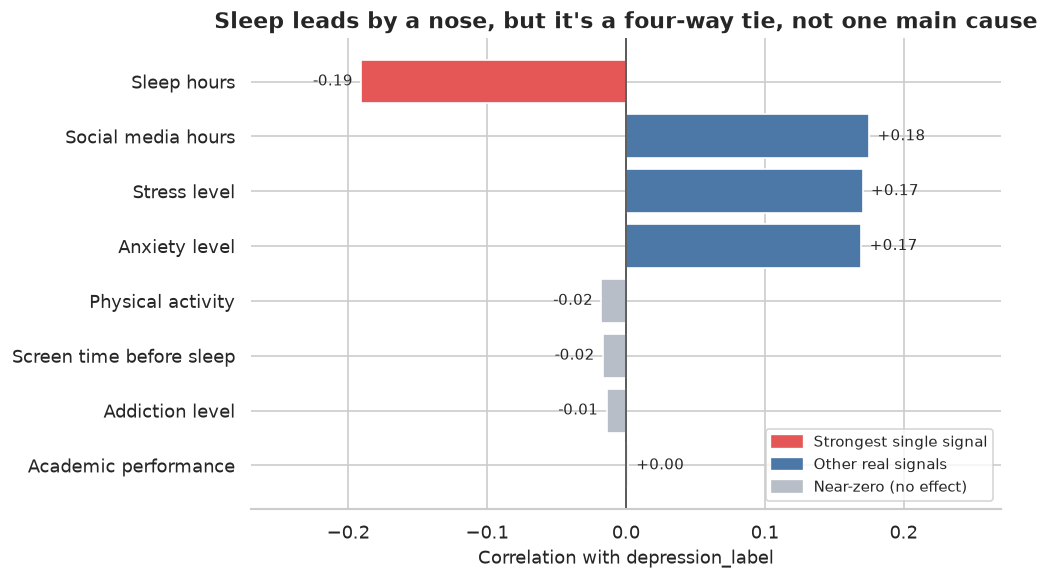

In [8]:
from matplotlib.patches import Patch

factor_labels = {
    "sleep_hours": "Sleep hours",
    "daily_social_media_hours": "Social media hours",
    "stress_level": "Stress level",
    "anxiety_level": "Anxiety level",
    "addiction_level": "Addiction level",
    "screen_time_before_sleep": "Screen time before sleep",
    "physical_activity": "Physical activity",
    "academic_performance": "Academic performance",
}
corr = (
    df[list(factor_labels) + ["depression_label"]]
    .corr()["depression_label"]
    .drop("depression_label")
)
corr = corr.reindex(corr.abs().sort_values().index)
strongest = corr.abs().idxmax()
bar_colors = [
    ACCENT if name == strongest else (BLUE if abs(v) >= 0.1 else BASE)
    for name, v in corr.items()
]

fig, ax = plt.subplots(figsize=(8.6, 5))
bars = ax.barh([factor_labels[i] for i in corr.index], corr.values, color=bar_colors)
for bar, v in zip(bars, corr.values):
    ax.text(v + (0.006 if v >= 0 else -0.006), bar.get_y() + bar.get_height() / 2,
            f"{v:+.2f}", va="center", ha="left" if v >= 0 else "right", fontsize=9)
ax.axvline(0, color="#444444", lw=1)
ax.set_xlim(-0.27, 0.27)
ax.set_xlabel("Correlation with depression_label")
ax.set_title("Sleep leads by a nose, but it's a four-way tie, not one main cause")
ax.legend(
    handles=[
        Patch(color=ACCENT, label="Strongest single signal"),
        Patch(color=BLUE, label="Other real signals"),
        Patch(color=BASE, label="Near-zero (no effect)"),
    ],
    loc="lower right", frameon=True, fontsize=9,
)
sns.despine(ax=ax, left=True)
plt.tight_layout()
plt.savefig(FIG_DIR / "06_factor_correlation.png", bbox_inches="tight")
plt.show()

## Chart 7. Does sleep *drive* stress and anxiety? Test it directly

If sleep were the root cause, short sleep should travel with high stress and high anxiety. Plot them against each other, read the correlation, and see where the flagged teens actually sit.

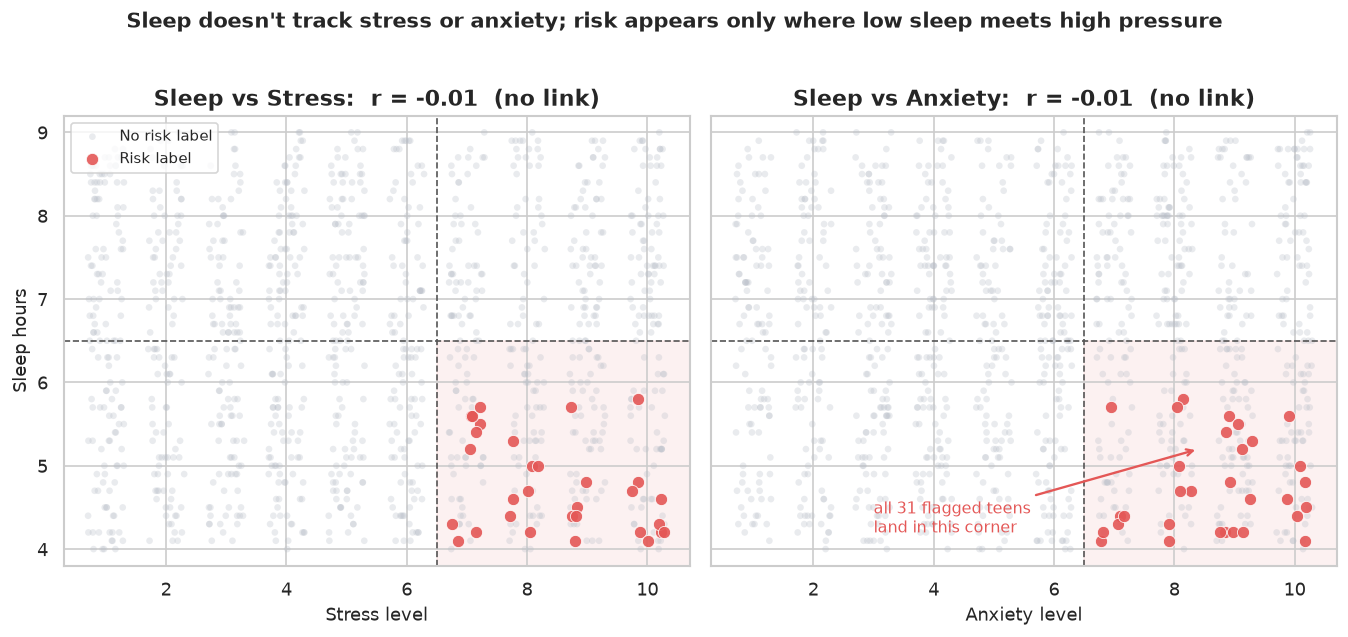

In [9]:
from matplotlib.patches import Rectangle

rng = np.random.default_rng(7)
fig, axes = plt.subplots(1, 2, figsize=(11.4, 5.4), sharey=True)
no_risk_mask = df["depression_label"] == 0
for ax, col, name in [(axes[0], "stress_level", "Stress"), (axes[1], "anxiety_level", "Anxiety")]:
    ax.add_patch(Rectangle((6.5, 3.8), 10.7 - 6.5, 6.5 - 3.8, color=ACCENT, alpha=0.08, zorder=0))
    jitter_x = df[col] + rng.uniform(-0.3, 0.3, len(df))
    ax.scatter(jitter_x[no_risk_mask], df["sleep_hours"][no_risk_mask], s=16, color=BASE,
               alpha=0.30, edgecolor="none", label="No risk label", zorder=1)
    ax.scatter(jitter_x[~no_risk_mask], df["sleep_hours"][~no_risk_mask], s=54, color=ACCENT,
               alpha=0.9, edgecolor="white", linewidth=0.5, label="Risk label", zorder=2)
    ax.axhline(6.5, color="#555555", ls="--", lw=1)
    ax.axvline(6.5, color="#555555", ls="--", lw=1)
    r = df["sleep_hours"].corr(df[col])
    ax.set_title(f"Sleep vs {name}:  r = {r:+.2f}  (no link)")
    ax.set_xlabel(f"{name} level")
    ax.set_xlim(0.3, 10.7)
axes[0].set_ylabel("Sleep hours")
axes[0].set_ylim(3.8, 9.2)
axes[0].legend(loc="upper left", frameon=True, fontsize=9)
axes[1].annotate("all 31 flagged teens\nland in this corner", xy=(8.4, 5.2), xytext=(3.0, 4.2),
                 arrowprops=dict(arrowstyle="->", color=ACCENT, lw=1.4), color=ACCENT,
                 fontsize=9.5, ha="left")
fig.suptitle("Sleep doesn't track stress or anxiety; risk appears only where low sleep meets high pressure",
             fontsize=12.5, fontweight="bold")
plt.tight_layout(rect=(0, 0, 1, 0.96))
plt.savefig(FIG_DIR / "07_sleep_vs_pressure.png", bbox_inches="tight")
plt.show()